In [15]:
import pandas as pd
import os, sys, re
import numpy as np
import torch.nn as nn
from sklearn.feature_selection import SelectKBest, f_regression
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import random
import copy
import torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler


# Import Dataset and Tidy

In [16]:
train_data = pd.read_csv("./data/covid.train.csv")
test_data = pd.read_csv("./data/covid.test.csv")

In [17]:
test_data

,id,AL,AK,AZ,AR,CA,CO,CT,FL,GA,...,shop.2,restaurant.2,spent_time.2,large_event.2,public_transit.2,anxious.2,depressed.2,felt_isolated.2,worried_become_ill.2,worried_finances.2
0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,52.071090,8.624001,29.374792,5.391413,2.754804,19.695098,13.685645,24.747837,66.194950,44.873473
1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,58.742461,21.720187,41.375784,9.450179,3.150088,22.075715,17.302077,23.559622,57.015009,38.372829
2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,59.109045,20.123959,40.072556,8.781522,2.888209,23.920870,18.342506,24.993341,55.291498,38.907257
3,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,55.442267,16.083529,36.977612,5.199286,2.575347,21.073800,12.087171,18.608723,67.036197,43.142779
4,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,60.588783,19.503010,42.631236,11.549771,8.530551,15.896575,11.781634,15.065228,61.196518,43.574676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
888,888,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,56.762931,21.494159,44.202567,14.996865,2.291745,17.740003,12.822676,18.123344,60.417531,37.156229
889,889,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,57.888461,16.770893,37.373472,7.169675,2.631595,20.587449,15.960166,23.710310,58.758735,38.673787
890,890,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,57.589848,16.761311,36.874822,11.046907,1.912310,16.800220,13.280423,22.423640,60.934851,43.122513
891,891,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,57.966384,22.696669,45.350415,20.343487,2.385330,16.528265,15.092539,17.476063,54.862386,44.016255


In [18]:
train_data

,id,AL,AK,AZ,AR,CA,CO,CT,FL,GA,...,restaurant.2,spent_time.2,large_event.2,public_transit.2,anxious.2,depressed.2,felt_isolated.2,worried_become_ill.2,worried_finances.2,tested_positive.2
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.812411,43.430423,16.151527,1.602635,15.409449,12.088688,16.702086,53.991549,43.604229,20.704935
1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.682974,43.196313,16.123386,1.641863,15.230063,11.809047,16.506973,54.185521,42.665766,21.292911
2,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.593983,43.362200,16.159971,1.677523,15.717207,12.355918,16.273294,53.637069,42.972417,21.166656
3,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,22.576992,42.954574,15.544373,1.578030,15.295650,12.218123,16.045504,52.446223,42.907472,19.896607
4,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,22.091433,43.290957,15.214655,1.641667,14.778802,12.417256,16.134238,52.560315,43.321985,20.178428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2695,2695,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,15.090116,30.839219,7.849525,1.760094,14.617563,11.163213,18.742673,68.024690,38.920206,13.008853
2696,2696,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,14.779264,30.617100,7.754800,1.780730,14.513419,11.281241,18.539741,67.855755,39.224244,12.725638
2697,2697,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,14.961085,30.595194,7.744075,1.921828,14.160990,11.163526,18.702564,67.731162,38.740651,12.613441
2698,2698,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,14.609582,30.420998,7.687974,1.992580,14.409427,11.330301,19.134697,67.795100,38.595125,12.477227


## Baseline 0
先用 sklearn 快速確認「資料整理 + 評估流程」都正確。

In [19]:
# 從 training dataset 中分離出 validation dataset
X = train_data.drop(columns=['id', 'tested_positive.2'])
y = train_data['tested_positive.2'] # day3 percentage
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 標準化
scaler = StandardScaler() # 建立一個「標準化器」
X_train_s = scaler.fit_transform(X_train)

# 沿用上方平均數與標準差來校正 val
X_val_s = scaler.transform(X_val)


# ------------------------------------
# baseline 0 (如果我們預測出來 day3 = day2，loss 會是多少？)
pred_b0 = X_val["tested_positive.1"].to_numpy(dtype=np.float64) 
loss_b0 = mean_squared_error(y_val, pred_b0)
print(f"MSE of baseline 0 (predict y3=y2): {loss_b0}")

MSE of baseline 0 (predict y3=y2): 1.0638112270372913


# Baseline 1
建立 Ridge MODEL（y = wx+b），alpha 是懲罰 ｗ 機制，讓 w 不要太大 -> alpha 越小，model 越接近線性模型，擬合更貼但更可能 overfit；alpha 越大，model 越保守較不容易 overfit


In [20]:
# 測試不同 alpha 的 model

best_alpha_loss = {"alpha":0, "loss":10}

for a in list(np.arange(0.01, 2.0001, 0.01)):
    model = Ridge(alpha=a)
    model.fit(X_train_s, y_train)
    pred = model.predict(X_val_s)
    loss = mean_squared_error(y_val, pred)
    if loss < best_alpha_loss["loss"] and loss < loss_b0:
        best_alpha_loss["alpha"] = a
        best_alpha_loss["loss"] = loss

print(f"best alpha: {best_alpha_loss['alpha']}, MSE of baseline 1: {best_alpha_loss['loss']}")

best alpha: 0.01, MSE of baseline 1: 0.9291660509752497


# PyTorch

### helper functions

In [21]:
# Keep the pipeline intentionally flat: all raw features go into SelectKBest,
# and we only add the smallest amount of validation / ensembling logic.

def set_seed(seed: int, deterministic: bool = True):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        if deterministic:
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False

STATE_ABBR = [
    'AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'FL', 'GA', 'ID',
    'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'MD', 'MA', 'MI', 'MN',
    'MS', 'MO', 'NE', 'NV', 'NJ', 'NM', 'NY', 'NC', 'OH', 'OK',
    'OR', 'PA', 'RI', 'SC', 'TX', 'UT', 'VA', 'WA', 'WV', 'WI',
]
SURVEY_COLS = [
    'cli', 'ili', 'hh_cmnty_cli', 'nohh_cmnty_cli', 'wearing_mask',
    'travel_outside_state', 'work_outside_home', 'shop', 'restaurant',
    'spent_time', 'large_event', 'public_transit', 'anxious', 'depressed',
    'felt_isolated', 'worried_become_ill', 'worried_finances',
]
STATE_COLS = [f'state_{abbr}' for abbr in STATE_ABBR]
DAY1_TP_COL = 'd1_tested_positive'
DAY2_TP_COL = 'd2_tested_positive'
TARGET_COL = 'd3_tested_positive'
SELECT_K = 16
BLEND_GRID = np.linspace(0.0, 1.0, 21)


def rename_covid_columns(df, has_day3_target: bool):
    renamed = ['id'] + STATE_COLS
    for day in (1, 2, 3):
        renamed.extend([f'd{day}_{name}' for name in SURVEY_COLS])
        if day < 3 or has_day3_target:
            renamed.append(f'd{day}_tested_positive')
    out = df.copy()
    out.columns = renamed
    return out


def state_ids(df):
    return df[STATE_COLS].to_numpy(dtype=np.float32).argmax(axis=1)


def split_state_timewise(df, val_frac=0.2, min_val_per_state=10):
    sids = state_ids(df)
    tr_idx = []
    va_idx = []
    for s in range(len(STATE_COLS)):
        idx = np.flatnonzero(sids == s)
        if len(idx) == 0:
            continue
        val_count = max(min_val_per_state, int(round(len(idx) * val_frac)))
        val_count = min(val_count, len(idx) - 1)
        tr_idx.extend(idx[:-val_count].tolist())
        va_idx.extend(idx[-val_count:].tolist())
    return df.iloc[tr_idx].copy(), df.iloc[va_idx].copy()


def build_flat_bank(df):
    flat = pd.DataFrame(index=df.index)
    for col in STATE_COLS:
        flat[col] = df[col].astype(np.float32)
    for day in (1, 2, 3):
        for name in SURVEY_COLS:
            flat[f'd{day}_{name}'] = df[f'd{day}_{name}'].astype(np.float32)
    flat[DAY1_TP_COL] = df[DAY1_TP_COL].astype(np.float32)
    flat[DAY2_TP_COL] = df[DAY2_TP_COL].astype(np.float32)
    return flat.astype(np.float32)


def select_and_scale(train_df, val_df, y_train, candidate_cols, k):
    k = min(int(k), len(candidate_cols))
    selector = SelectKBest(score_func=f_regression, k=k)
    selector.fit(train_df[candidate_cols], y_train)
    selected_cols = [col for col, keep in zip(candidate_cols, selector.get_support()) if keep]

    scaler = StandardScaler()
    train_s = scaler.fit_transform(train_df[selected_cols]).astype(np.float32)
    val_s = scaler.transform(val_df[selected_cols]).astype(np.float32)
    return selected_cols, scaler, train_s, val_s


def make_tensor_loader(X_s, y, batch_size: int, shuffle: bool, seed: int):
    dataset = TensorDataset(
        torch.tensor(X_s, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32).reshape(-1, 1),
    )
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator,
        num_workers=0,
    )


class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden=64, dropout=0.15, depth=2):
        super().__init__()
        layers = []
        dim = input_dim
        for _ in range(max(1, depth)):
            layers.extend([
                nn.Linear(dim, hidden),
                nn.LayerNorm(hidden),
                nn.GELU(),
                nn.Dropout(dropout),
            ])
            dim = hidden
        layers.append(nn.Linear(dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def evaluate_mse(model, loader, device):
    model.eval()
    preds = []
    targets = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            preds.append(model(xb))
            targets.append(yb)
    pred = torch.cat(preds, dim=0)
    target = torch.cat(targets, dim=0)
    return F.mse_loss(pred, target).item()


@torch.no_grad()
def predict_numpy(model, X_s, device, batch_size=256):
    model.eval()
    loader = DataLoader(
        TensorDataset(torch.tensor(X_s, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )
    preds = []
    for (xb,) in loader:
        preds.append(model(xb.to(device)).cpu().numpy())
    return np.vstack(preds).reshape(-1)


def train_simple_mlp(
    model,
    train_loader,
    val_loader,
    device,
    epochs=300,
    lr=1e-3,
    weight_decay=1e-3,
    patience=40,
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=10,
        min_lr=1e-5,
    )

    best_state = None
    best_epoch = 0
    best_val = float('inf')
    bad_count = 0
    train_hist = []
    val_hist = []

    model.to(device)

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            loss = F.mse_loss(pred, yb)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        train_mse = evaluate_mse(model, train_loader, device)
        val_mse = evaluate_mse(model, val_loader, device)
        train_hist.append(train_mse)
        val_hist.append(val_mse)
        scheduler.step(val_mse)

        if val_mse < best_val - 1e-8:
            best_val = val_mse
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            bad_count = 0
        else:
            bad_count += 1
            if bad_count >= patience:
                print(f'Early stopping at epoch {epoch}. Best epoch = {best_epoch}, best va_mse = {best_val:.4f}')
                break

        if epoch <= 20 or epoch % 10 == 0 or val_mse <= best_val + 1e-8:
            print(f'epoch {epoch}: tr_mse={train_mse:.4f}, va_mse={val_mse:.4f}')

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, train_hist, val_hist, best_epoch, best_val


def fit_full_mlp(
    model,
    train_loader,
    device,
    epochs=120,
    lr=1e-3,
    weight_decay=1e-3,
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    model.to(device)

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_n = 0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            loss = F.mse_loss(pred, yb)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += float(loss.item()) * len(xb)
            total_n += len(xb)

        train_mse = total_loss / max(total_n, 1)
        if epoch <= 20 or epoch % 10 == 0 or epoch == epochs:
            print(f'final epoch {epoch}/{epochs}: train_mse={train_mse:.4f}')

    return model


def choose_blend_weight(y_true, pred_a, pred_b, grid=None):
    if grid is None:
        grid = BLEND_GRID
    y_true = np.asarray(y_true, dtype=np.float32).reshape(-1)
    pred_a = np.asarray(pred_a, dtype=np.float32).reshape(-1)
    pred_b = np.asarray(pred_b, dtype=np.float32).reshape(-1)
    best_w = 1.0
    best_score = float('inf')
    for w in grid:
        pred = w * pred_a + (1.0 - w) * pred_b
        score = mean_squared_error(y_true, pred)
        if score < best_score:
            best_score = score
            best_w = float(w)
    return best_w, best_score

# Flat Feature Selection + Simple MLP

把 40 states 和三天的 raw features 全部丟進 `SelectKBest`，固定 `k=16`，不再加 state-aware、residual、calibration 這些額外結構。

In [22]:
train_df = rename_covid_columns(train_data, has_day3_target=True)
test_df = rename_covid_columns(test_data, has_day3_target=False)

outer_train_df, outer_val_df = split_state_timewise(train_df, val_frac=0.2, min_val_per_state=10)
y_outer_train = outer_train_df[TARGET_COL].to_numpy(dtype=np.float32)
y_outer_val = outer_val_df[TARGET_COL].to_numpy(dtype=np.float32)

flat_outer_train_bank = build_flat_bank(outer_train_df)
flat_outer_val_bank = build_flat_bank(outer_val_df)

day2_outer_train = outer_train_df[DAY2_TP_COL].to_numpy(dtype=np.float32)
day2_outer_val = outer_val_df[DAY2_TP_COL].to_numpy(dtype=np.float32)

print(f'train_df shape = {train_df.shape}')
print(f'test_df shape = {test_df.shape}')
print(f'outer_train rows = {len(outer_train_df)}, outer_val rows = {len(outer_val_df)}')
print(f'flat bank columns = {flat_outer_train_bank.shape[1]}')
print(f'day2 baseline val MSE = {mean_squared_error(y_outer_val, day2_outer_val):.4f}')

train_df shape = (2700, 95)
test_df shape = (893, 94)
outer_train rows = 2160, outer_val rows = 540
flat bank columns = 93
day2 baseline val MSE = 1.3434


## Feature Selection

In [23]:
candidate_cols = flat_outer_train_bank.columns.tolist()
selected_cols, feature_scaler, X_outer_train_s, X_outer_val_s = select_and_scale(
    flat_outer_train_bank,
    flat_outer_val_bank,
    y_outer_train,
    candidate_cols,
    SELECT_K,
)

print(f'SELECT_K = {SELECT_K}')
print(f'selected feature count = {len(selected_cols)}')
print(f'X_outer_train_s shape = {X_outer_train_s.shape}')
print(f'X_outer_val_s shape = {X_outer_val_s.shape}')
print('selected cols:')
print(selected_cols)

SELECT_K = 16
selected feature count = 16
X_outer_train_s shape = (2160, 16)
X_outer_val_s shape = (540, 16)
selected cols:
['d1_cli', 'd1_ili', 'd1_hh_cmnty_cli', 'd1_nohh_cmnty_cli', 'd2_cli', 'd2_ili', 'd2_hh_cmnty_cli', 'd2_nohh_cmnty_cli', 'd2_worried_finances', 'd3_cli', 'd3_ili', 'd3_hh_cmnty_cli', 'd3_nohh_cmnty_cli', 'd3_worried_finances', 'd1_tested_positive', 'd2_tested_positive']


## Train MLP

In [24]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seed = 2025
set_seed(seed)

batch_size = 64
hidden = 64
depth = 2
dropout = 0.15
lr = 1e-3
weight_decay = 1e-3
epochs = 300
patience = 40

train_loader = make_tensor_loader(X_outer_train_s, y_outer_train, batch_size=batch_size, shuffle=True, seed=seed)
val_loader = make_tensor_loader(X_outer_val_s, y_outer_val, batch_size=batch_size, shuffle=False, seed=seed)

model = SimpleMLP(input_dim=X_outer_train_s.shape[1], hidden=hidden, dropout=dropout, depth=depth)
model, train_hist, val_hist, best_epoch, best_val = train_simple_mlp(
    model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=epochs,
    lr=lr,
    weight_decay=weight_decay,
    patience=patience,
)

outer_val_pred_mlp = predict_numpy(model, X_outer_val_s, device)
blend_weight, blend_val_mse = choose_blend_weight(y_outer_val, outer_val_pred_mlp, day2_outer_val)

print(f'outer val MLP MSE = {mean_squared_error(y_outer_val, outer_val_pred_mlp):.4f}')
print(f'outer val blend MSE = {blend_val_mse:.4f}')
print(f'outer val day2 baseline MSE = {mean_squared_error(y_outer_val, day2_outer_val):.4f}')
print(f'best epoch = {best_epoch}')
print(f'blend weight for MLP = {blend_weight:.2f}')

epoch 1: tr_mse=207.1039, va_mse=301.6110
epoch 2: tr_mse=161.6639, va_mse=243.4189
epoch 3: tr_mse=126.3929, va_mse=195.2068
epoch 4: tr_mse=96.4951, va_mse=151.8878
epoch 5: tr_mse=68.4449, va_mse=113.4670
epoch 6: tr_mse=46.9490, va_mse=80.5885
epoch 7: tr_mse=29.9379, va_mse=54.1408
epoch 8: tr_mse=17.7761, va_mse=34.1702
epoch 9: tr_mse=9.4787, va_mse=20.8567
epoch 10: tr_mse=5.0488, va_mse=13.5423
epoch 11: tr_mse=3.0947, va_mse=9.5110
epoch 12: tr_mse=2.2876, va_mse=7.4650
epoch 13: tr_mse=2.4808, va_mse=6.9161
epoch 14: tr_mse=2.0249, va_mse=5.9932
epoch 15: tr_mse=1.7471, va_mse=5.3359
epoch 16: tr_mse=1.5150, va_mse=4.9169
epoch 17: tr_mse=1.6353, va_mse=4.4639
epoch 18: tr_mse=1.4246, va_mse=4.2676
epoch 19: tr_mse=1.3450, va_mse=3.9833
epoch 20: tr_mse=1.2852, va_mse=3.8539
epoch 21: tr_mse=1.3359, va_mse=3.6932
epoch 23: tr_mse=1.2181, va_mse=3.3856
epoch 24: tr_mse=1.2060, va_mse=3.2727
epoch 25: tr_mse=1.3178, va_mse=3.1920
epoch 27: tr_mse=1.2764, va_mse=3.0778
epoch 28

## Epoch Curve

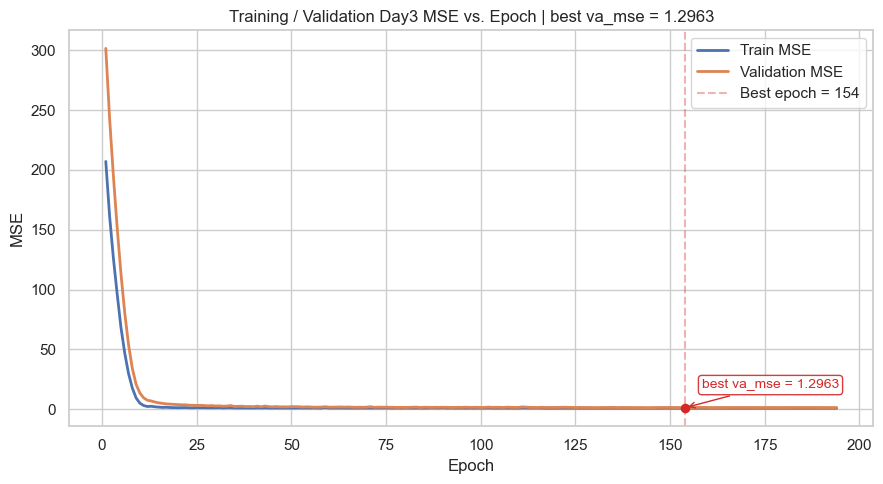

In [25]:
sns.set_theme(style='whitegrid')
epochs_ran = np.arange(1, len(train_hist) + 1)
best_epoch_plot = best_epoch if best_epoch is not None else int(np.argmin(val_hist) + 1)
best_va_mse = val_hist[best_epoch_plot - 1]

plt.figure(figsize=(9, 5))
plt.plot(epochs_ran, train_hist, label='Train MSE', linewidth=2)
plt.plot(epochs_ran, val_hist, label='Validation MSE', linewidth=2)
plt.axvline(best_epoch_plot, color='tab:red', linestyle='--', alpha=0.35, label=f'Best epoch = {best_epoch_plot}')
plt.scatter(best_epoch_plot, best_va_mse, color='tab:red', s=35, zorder=3)
plt.annotate(
    f'best va_mse = {best_va_mse:.4f}',
    xy=(best_epoch_plot, best_va_mse),
    xytext=(12, 14),
    textcoords='offset points',
    fontsize=10,
    color='tab:red',
    bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='tab:red', alpha=0.9),
    arrowprops=dict(arrowstyle='->', color='tab:red', lw=1),
)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title(f'Training / Validation Day3 MSE vs. Epoch | best va_mse = {best_va_mse:.4f}')
plt.legend()
plt.tight_layout()
plt.show()

## Final Fit and Submission

In [26]:
# Refit the same flat pipeline on the full training set, then create submission.csv.
full_train_df = rename_covid_columns(train_data, has_day3_target=True)
full_test_df = rename_covid_columns(test_data, has_day3_target=False)
y_full = full_train_df[TARGET_COL].to_numpy(dtype=np.float32)

full_flat_train_bank = build_flat_bank(full_train_df)
full_flat_test_bank = build_flat_bank(full_test_df)

full_selected_cols, full_feature_scaler, X_full_train_s, X_full_test_s = select_and_scale(
    full_flat_train_bank,
    full_flat_test_bank,
    y_full,
    full_flat_train_bank.columns.tolist(),
    SELECT_K,
)

set_seed(seed)
final_model = SimpleMLP(input_dim=X_full_train_s.shape[1], hidden=hidden, dropout=dropout, depth=depth)
final_train_loader = make_tensor_loader(X_full_train_s, y_full, batch_size=batch_size, shuffle=True, seed=seed)
final_epochs = max(100, int(round((best_epoch or 100) * 1.2)))
final_model = fit_full_mlp(
    final_model,
    train_loader=final_train_loader,
    device=device,
    epochs=final_epochs,
    lr=lr,
    weight_decay=weight_decay,
)

mlp_test_pred = predict_numpy(final_model, X_full_test_s, device)
day2_test_pred = full_test_df[DAY2_TP_COL].to_numpy(dtype=np.float32)
final_test = blend_weight * mlp_test_pred + (1.0 - blend_weight) * day2_test_pred
final_test = np.clip(final_test, 0.0, 100.0)

submission = pd.DataFrame({
    'id': full_test_df['id'].to_numpy(),
    'tested_positive': final_test,
})
submission.to_csv('submission.csv', index=False)

import subprocess
subprocess.run([
    'kaggle', 'competitions', 'submit',
    '-c', 'ml2021spring-hw1',
    '-f', 'submission.csv',
    '-m', f'flat SelectKBest k={SELECT_K} + simple MLP',
], check=True)

print(f'final blend weight = {blend_weight:.2f}')
print(f'final training epochs = {final_epochs}')
print('Saved submission.csv and submitted to Kaggle')
submission.head()

final epoch 1/185: train_mse=264.3917
final epoch 2/185: train_mse=187.3975
final epoch 3/185: train_mse=138.1533
final epoch 4/185: train_mse=97.6229
final epoch 5/185: train_mse=64.4347
final epoch 6/185: train_mse=38.2299
final epoch 7/185: train_mse=21.2013
final epoch 8/185: train_mse=12.1203
final epoch 9/185: train_mse=8.1164
final epoch 10/185: train_mse=6.1031
final epoch 11/185: train_mse=5.2893
final epoch 12/185: train_mse=4.8550
final epoch 13/185: train_mse=4.9045
final epoch 14/185: train_mse=4.6800
final epoch 15/185: train_mse=4.4466
final epoch 16/185: train_mse=4.1708
final epoch 17/185: train_mse=3.9143
final epoch 18/185: train_mse=3.9880
final epoch 19/185: train_mse=4.0865
final epoch 20/185: train_mse=3.6675
final epoch 30/185: train_mse=3.3436
final epoch 40/185: train_mse=2.9312
final epoch 50/185: train_mse=2.8178
final epoch 60/185: train_mse=2.7028
final epoch 70/185: train_mse=2.6648
final epoch 80/185: train_mse=2.4509
final epoch 90/185: train_mse=2.3189

100%|██████████| 11.8k/11.8k [00:01<00:00, 10.8kB/s]


Successfully submitted to ML2021Spring-hw1final blend weight = 0.55
final training epochs = 185
Saved submission.csv and submitted to Kaggle


,id,tested_positive
0,0,20.752630
1,1,2.501551
2,2,2.589028
3,3,11.208481
4,4,2.749244
